#  The Complete Pandas Tutorial: Beginner to Expert

**Version:** Pandas 2.x Compatible  

---

This notebook is a self-contained, end-to-end tutorial covering **everything** you need to know about Pandas — from your very first `import pandas as pd` to advanced performance optimization, window functions, and MultiIndex magic.

###  Table of Contents

| # | Section | Level |
|---|---------|-------|
| 1 | Introduction & Setup |  Beginner |
| 2 | Core Data Structures: Series & DataFrame |  Beginner |
| 3 | Creating DataFrames |  Beginner |
| 4 | Reading & Writing Data (I/O) |  Beginner |
| 5 | Data Inspection & Summary Statistics |  Beginner |
| 6 | Indexing & Selection |  Intermediate |
| 7 | Boolean Indexing & Filtering |  Intermediate |
| 8 | Handling Missing Data |  Intermediate |
| 9 | Data Cleaning & Transformation |  Intermediate |
| 10 | String Operations (str accessor) |  Intermediate |
| 11 | DateTime Operations |  Intermediate |
| 12 | Sorting & Ranking |  Intermediate |
| 13 | GroupBy & Aggregation |  Advanced |
| 14 | Merging, Joining & Concatenation |  Advanced |
| 15 | Reshaping: Pivot, Melt, Stack, Unstack |  Advanced |
| 16 | Apply, Map & Lambda Functions |  Advanced |
| 17 | MultiIndex (Hierarchical Indexing) |  Expert |
| 18 | Window Functions: Rolling & Expanding |  Expert |
| 19 | Categorical Data |  Expert |
| 20 | Performance & Memory Optimization |  Expert |
| 21 | Method Chaining & Pipes |  Expert |
| 22 | Visualization with Pandas |  Intermediate |

---

> **Tip:** Run cells sequentially — later sections depend on variables defined earlier.

---
##  Section 1 — Introduction & Setup

Pandas is the **de-facto** data manipulation library in Python. It provides two primary data structures:
- **Series** — a 1D labeled array
- **DataFrame** — a 2D labeled table (think: supercharged Excel sheet)

Pandas is built on top of **NumPy** and integrates seamlessly with **Matplotlib**, **Scikit-learn**, **SciPy**, and virtually every ML/data-science library in the ecosystem.

### Installation
```bash
pip install pandas numpy matplotlib openpyxl
```

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 30)
pd.set_option('display.max_rows', 60)
pd.set_option('display.width', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

print(f'Pandas  version : {pd.__version__}')
print(f'NumPy   version : {np.__version__}')

Pandas  version : 3.0.3
NumPy   version : 2.4.6


---
## Section 2 — Core Data Structures: Series & DataFrame

### 2.1 Series

A **Series** is a one-dimensional labeled array capable of holding any data type (integers, floats, strings, Python objects, etc.).  
Think of it as a column from a spreadsheet, but with a powerful index attached.

```
index    values
  a   →    10
  b   →    20
  c   →    30
```

In [2]:
# --- Creating a Series ---

# From a list (default integer index)
s1 = pd.Series([10, 20, 30, 40, 50])
print('Series from list:')
print(s1)
print()

Series from list:
0    10
1    20
2    30
3    40
4    50
dtype: int64



In [3]:
# From a list with a custom index
s2 = pd.Series([10, 20, 30, 40, 50], index=['a', 'b', 'c', 'd', 'e'], name='my_series')
print('Series with custom index:')
print(s2)
print()

# From a dict — keys become the index automatically
s3 = pd.Series({'apple': 1.5, 'banana': 0.75, 'cherry': 3.0})
print('Series from dict:')
print(s3)

Series with custom index:
a    10
b    20
c    30
d    40
e    50
Name: my_series, dtype: int64

Series from dict:
apple    1.5000
banana   0.7500
cherry   3.0000
dtype: float64


In [4]:
# --- Key Series attributes ---
print('Values :', s2.values)          # Underlying NumPy array
print('Index  :', s2.index.tolist())  # Index object
print('dtype  :', s2.dtype)           # Data type
print('Name   :', s2.name)            # Series name
print('Shape  :', s2.shape)           # Tuple (n,)
print('Size   :', s2.size)            # Total elements

Values : [10 20 30 40 50]
Index  : ['a', 'b', 'c', 'd', 'e']
dtype  : int64
Name   : my_series
Shape  : (5,)
Size   : 5


In [5]:
# --- Vectorised arithmetic on Series (like NumPy arrays) ---
print(s2 * 2)       # Element-wise multiplication
print()
print(s2 + s2)      # Element-wise addition (aligns on index)

a     20
b     40
c     60
d     80
e    100
Name: my_series, dtype: int64

a     20
b     40
c     60
d     80
e    100
Name: my_series, dtype: int64


### 2.2 DataFrame

A **DataFrame** is a 2-dimensional, size-mutable, heterogeneous tabular data structure with labeled axes (rows and columns).  
You can think of it as a dictionary of Series objects that share the same index, or as a 2D NumPy array with row and column labels.

```
         name   age   salary
index
  0      Alice   28   70000
  1      Bob     34   90000
  2      Carol   22   55000
```

In [6]:
# Build our running example DataFrame that we'll use throughout this notebook
np.random.seed(42)

data = {
    'name':       ['Alice', 'Bob', 'Carol', 'Dave', 'Eve',
                   'Frank', 'Grace', 'Heidi', 'Ivan', 'Judy'],
    'age':        [28, 34, 22, 45, 31, 29, 37, 26, 41, 33],
    'department': ['Engineering', 'Marketing', 'Engineering', 'HR',
                   'Marketing', 'Engineering', 'HR', 'Marketing',
                   'Engineering', 'HR'],
    'salary':     [72000, 58000, 68000, 85000, 61000,
                   77000, 90000, 54000, 83000, 70000],
    'experience': [4.0, 8.0, 1.0, 20.0, 6.0, 3.0, 12.0, 2.0, 16.0, 9.0],
    'remote':     [True, False, True, False, True,
                   True, False, True, False, True],
    'rating':     [4.5, 3.8, 4.2, 4.9, 3.5, 4.1, 4.7, 3.3, 4.6, 4.0],
    'joined':     pd.to_datetime([
                   '2020-03-15', '2016-07-01', '2023-01-10', '2004-06-20',
                   '2018-11-05', '2021-08-22', '2012-04-30', '2022-06-01',
                   '2008-09-15', '2015-02-28'
                  ])
}

df = pd.DataFrame(data)
print('Shape:', df.shape)  # (rows, cols)
df

Shape: (10, 8)


,name,age,department,salary,experience,remote,rating,joined
0,Alice,28,Engineering,72000,4.0000,True,4.5000,2020-03-15
1,Bob,34,Marketing,58000,8.0000,False,3.8000,2016-07-01
2,Carol,22,Engineering,68000,1.0000,True,4.2000,2023-01-10
3,Dave,45,HR,85000,20.0000,False,4.9000,2004-06-20
4,Eve,31,Marketing,61000,6.0000,True,3.5000,2018-11-05
5,Frank,29,Engineering,77000,3.0000,True,4.1000,2021-08-22
6,Grace,37,HR,90000,12.0000,False,4.7000,2012-04-30
7,Heidi,26,Marketing,54000,2.0000,True,3.3000,2022-06-01
8,Ivan,41,Engineering,83000,16.0000,False,4.6000,2008-09-15
9,Judy,33,HR,70000,9.0000,True,4.0000,2015-02-28


In [7]:
# --- Key DataFrame attributes ---
print('Columns:', df.columns.tolist())
print('Index  :', df.index.tolist())
print('Dtypes :\n', df.dtypes)
print('\nndim   :', df.ndim)
print('Size   :', df.size)

Columns: ['name', 'age', 'department', 'salary', 'experience', 'remote', 'rating', 'joined']
Index  : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Dtypes :
 name                     str
age                    int64
department               str
salary                 int64
experience           float64
remote                  bool
rating               float64
joined        datetime64[us]
dtype: object

ndim   : 2
Size   : 80


---
## Section 3 — Creating DataFrames

DataFrames can be constructed from many sources. Knowing all the creation patterns saves time and avoids round-tripping through files.

In [8]:
# 1. From a dict of lists (most common)
df_dict = pd.DataFrame({'x': [1, 2, 3], 'y': [4, 5, 6]})
print('From dict of lists:')
print(df_dict, '\n')

# 2. From a list of dicts (rows as dicts)
df_rows = pd.DataFrame([
    {'product': 'Apple',  'price': 1.20, 'stock': 100},
    {'product': 'Banana', 'price': 0.50, 'stock': 200},
    {'product': 'Cherry', 'price': 3.00, 'stock': 50},
])
print('From list of dicts:')
print(df_rows, '\n')

From dict of lists:
   x  y
0  1  4
1  2  5
2  3  6 

From list of dicts:
  product  price  stock
0   Apple 1.2000    100
1  Banana 0.5000    200
2  Cherry 3.0000     50 



In [9]:
# 3. From a 2D NumPy array
arr = np.arange(12).reshape(3, 4)
df_np = pd.DataFrame(arr, columns=['A', 'B', 'C', 'D'], index=['r1', 'r2', 'r3'])
print('From NumPy array:')
print(df_np, '\n')

# 4. From a Series
df_series = pd.DataFrame(s3, columns=['price'])
print('From Series:')
print(df_series, '\n')

# 5. Empty DataFrame with defined schema
df_empty = pd.DataFrame(columns=['id', 'name', 'value'])
print('Empty DataFrame:')
print(df_empty)

From NumPy array:
    A  B   C   D
r1  0  1   2   3
r2  4  5   6   7
r3  8  9  10  11 

From Series:
        price
apple  1.5000
banana 0.7500
cherry 3.0000 

Empty DataFrame:
Empty DataFrame
Columns: [id, name, value]
Index: []


---
##  Section 4 — Reading & Writing Data (I/O)

Pandas supports **many file formats** out of the box. The `read_*` family of functions ingests data; the `to_*` family exports it.

| Format | Read | Write |
|--------|------|-------|
| CSV | `pd.read_csv()` | `df.to_csv()` |
| Excel | `pd.read_excel()` | `df.to_excel()` |
| JSON | `pd.read_json()` | `df.to_json()` |
| Parquet | `pd.read_parquet()` | `df.to_parquet()` |
| SQL | `pd.read_sql()` | `df.to_sql()` |
| HTML | `pd.read_html()` | `df.to_html()` |
| Clipboard | `pd.read_clipboard()` | `df.to_clipboard()` |

In [10]:
import io

# --- Saving and loading CSV (the most common format) ---
df.to_csv('employees.csv', index=False)  # index=False avoids writing the RangeIndex
df_loaded = pd.read_csv('employees.csv')
print(f'Loaded {len(df_loaded)} rows from CSV')
df_loaded.head(3)

Loaded 10 rows from CSV


,name,age,department,salary,experience,remote,rating,joined
0,Alice,28,Engineering,72000,4.0000,True,4.5000,2020-03-15
1,Bob,34,Marketing,58000,8.0000,False,3.8000,2016-07-01
2,Carol,22,Engineering,68000,1.0000,True,4.2000,2023-01-10


In [11]:
# --- read_csv key parameters ---
csv_data = """name,age,salary
Alice,28,72000
Bob,34,58000
Carol,22,68000"""

# Parse from an in-memory string (useful in tests)
df_demo = pd.read_csv(
    io.StringIO(csv_data),
    dtype={'age': int, 'salary': float},  # enforce types
    usecols=['name', 'salary'],            # load only specific columns
)
print(df_demo)
print(df_demo.dtypes)

    name     salary
0  Alice 72000.0000
1    Bob 58000.0000
2  Carol 68000.0000
name          str
salary    float64
dtype: object


In [12]:
# --- JSON round-trip ---
json_str = df.to_json(orient='records', date_format='iso')
df_from_json = pd.read_json(io.StringIO(json_str))
print('JSON round-trip shape:', df_from_json.shape)

JSON round-trip shape: (10, 8)


In [13]:
# --- Parquet (best for large datasets — columnar, compressed) ---
try:
    df.to_parquet('employees.parquet', index=False)
    df_parquet = pd.read_parquet('employees.parquet')
    print('Parquet round-trip OK:', df_parquet.shape)
except ImportError:
    print('Install pyarrow or fastparquet for Parquet support: pip install pyarrow')

Install pyarrow or fastparquet for Parquet support: pip install pyarrow


---
##  Section 5 — Data Inspection & Summary Statistics

Before analysing any dataset, always **inspect** it first. These methods give you a quick mental model of the data's shape, types, and health.

In [14]:
# --- First/last rows ---
print('=== head(3) ===')
print(df.head(3))
print('\n=== tail(3) ===')
print(df.tail(3))

=== head(3) ===
    name  age   department  salary  experience  remote  rating     joined
0  Alice   28  Engineering   72000      4.0000    True  4.5000 2020-03-15
1    Bob   34    Marketing   58000      8.0000   False  3.8000 2016-07-01
2  Carol   22  Engineering   68000      1.0000    True  4.2000 2023-01-10

=== tail(3) ===
    name  age   department  salary  experience  remote  rating     joined
7  Heidi   26    Marketing   54000      2.0000    True  3.3000 2022-06-01
8   Ivan   41  Engineering   83000     16.0000   False  4.6000 2008-09-15
9   Judy   33           HR   70000      9.0000    True  4.0000 2015-02-28


In [15]:
# --- Concise summary ---
df.info()  # Non-null counts, dtypes, memory usage

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   name        10 non-null     str           
 1   age         10 non-null     int64         
 2   department  10 non-null     str           
 3   salary      10 non-null     int64         
 4   experience  10 non-null     float64       
 5   remote      10 non-null     bool          
 6   rating      10 non-null     float64       
 7   joined      10 non-null     datetime64[us]
dtypes: bool(1), datetime64[us](1), float64(2), int64(2), str(2)
memory usage: 702.0 bytes


In [16]:
# --- Descriptive statistics (numeric columns) ---
df.describe()

,age,salary,experience,rating,joined
count,10.0000,10.0000,10.0000,10.0000,10
mean,32.6000,71800.0000,8.1000,4.1600,2016-04-30 02:24:00
min,22.0000,54000.0000,1.0000,3.3000,2004-06-20 00:00:00
25%,28.2500,62750.0000,3.2500,3.8500,2013-01-13 12:00:00
50%,32.0000,71000.0000,7.0000,4.1500,2017-09-02 12:00:00
75%,36.2500,81500.0000,11.2500,4.5750,2021-04-12 18:00:00
max,45.0000,90000.0000,20.0000,4.9000,2023-01-10 00:00:00
std,6.9793,12016.6551,6.2796,0.5254,NaN


In [17]:
# --- include='all' also covers object/boolean columns ---
df.describe(include='all')

,name,age,department,salary,experience,remote,rating,joined
count,10,10.0000,10,10.0000,10.0000,10,10.0000,10
unique,10,NaN,3,NaN,NaN,2,NaN,NaN
top,Alice,NaN,Engineering,NaN,NaN,True,NaN,NaN
freq,1,NaN,4,NaN,NaN,6,NaN,NaN
mean,NaN,32.6000,NaN,71800.0000,8.1000,NaN,4.1600,2016-04-30 02:24:00
min,NaN,22.0000,NaN,54000.0000,1.0000,NaN,3.3000,2004-06-20 00:00:00
25%,NaN,28.2500,NaN,62750.0000,3.2500,NaN,3.8500,2013-01-13 12:00:00
50%,NaN,32.0000,NaN,71000.0000,7.0000,NaN,4.1500,2017-09-02 12:00:00
75%,NaN,36.2500,NaN,81500.0000,11.2500,NaN,4.5750,2021-04-12 18:00:00
max,NaN,45.0000,NaN,90000.0000,20.0000,NaN,4.9000,2023-01-10 00:00:00


In [18]:
# --- Individual statistics ---
print('Mean salary  :', df['salary'].mean())
print('Median salary:', df['salary'].median())
print('Std salary   :', df['salary'].std())
print('Min / Max    :', df['salary'].min(), '/', df['salary'].max())
print('Skewness     :', df['salary'].skew())
print('Kurtosis     :', df['salary'].kurt())
print()
print('Value counts for department:')
print(df['department'].value_counts())
print()
print('Unique departments:', df['department'].unique())
print('Num unique       :', df['department'].nunique())

Mean salary  : 71800.0
Median salary: 71000.0
Std salary   : 12016.655108639841
Min / Max    : 54000 / 90000
Skewness     : 0.02287914111180286
Kurtosis     : -1.1256166549921973

Value counts for department:
department
Engineering    4
Marketing      3
HR             3
Name: count, dtype: int64

Unique departments: <StringArray>
['Engineering', 'Marketing', 'HR']
Length: 3, dtype: str
Num unique       : 3


In [19]:
# --- Correlation matrix (numeric only) ---
df[['age', 'salary', 'experience', 'rating']].corr()

,age,salary,experience,rating
age,1.0000,0.6269,0.9821,0.5952
salary,0.6269,1.0000,0.6585,0.9120
experience,0.9821,0.6585,1.0000,0.6581
rating,0.5952,0.9120,0.6581,1.0000


---
##  Section 6 — Indexing & Selection

Pandas provides **three** main indexers:

| Indexer | Selects by | Syntax |
|---------|------------|--------|
| `[]` | Column name / row slice | `df['col']`, `df[0:5]` |
| `.loc[]` | **Label** (row & col name) | `df.loc[row_label, col_label]` |
| `.iloc[]` | **Integer** position (0-based) | `df.iloc[row_int, col_int]` |

> **Golden rule:** Always use `.loc` or `.iloc` for reliable row+column selection. Using chained indexing (`df['col'][0]`) can trigger `SettingWithCopyWarning`.

In [20]:
# === Column selection ===

# Single column → Series
print(df['name'].head(3))
print(type(df['name']))
print()

0    Alice
1      Bob
2    Carol
Name: name, dtype: str
<class 'pandas.Series'>



In [21]:
# Multiple columns → DataFrame
df[['name', 'salary', 'department']].head(3)

,name,salary,department
0,Alice,72000,Engineering
1,Bob,58000,Marketing
2,Carol,68000,Engineering


In [22]:
# === .loc — label-based ===

# Single row by label
print(df.loc[2])
print()

name                        Carol
age                            22
department            Engineering
salary                      68000
experience                 1.0000
remote                       True
rating                     4.2000
joined        2023-01-10 00:00:00
Name: 2, dtype: object



In [23]:
# Slice of rows AND specific columns
# Note: .loc slicing is INCLUSIVE on both ends
df.loc[1:4, ['name', 'salary', 'rating']]

,name,salary,rating
1,Bob,58000,3.8000
2,Carol,68000,4.2000
3,Dave,85000,4.9000
4,Eve,61000,3.5000


In [24]:
# Specific cell
print('Cell (row=2, col=name):', df.loc[2, 'name'])

# All rows, specific columns
df.loc[:, 'age':'salary'].head(3)

Cell (row=2, col=name): Carol


,age,department,salary
0,28,Engineering,72000
1,34,Marketing,58000
2,22,Engineering,68000


In [25]:
# === .iloc — integer-position based ===

# Note: .iloc slicing is EXCLUSIVE on the right end (like Python lists)
df.iloc[0:3, 0:4]   # rows 0,1,2 and cols 0,1,2,3

,name,age,department,salary
0,Alice,28,Engineering,72000
1,Bob,34,Marketing,58000
2,Carol,22,Engineering,68000


In [26]:
# Last 2 rows, last 3 columns
df.iloc[-2:, -3:]

,remote,rating,joined
8,False,4.6000,2008-09-15
9,True,4.0000,2015-02-28


In [27]:
# === Setting values safely with .loc ===
df_copy = df.copy()
df_copy.loc[0, 'salary'] = 75000  # Safe assignment
print('Updated salary:', df_copy.loc[0, 'salary'])

Updated salary: 75000


In [28]:
# === at / iat — fast scalar access ===
print('.at  :', df.at[3, 'name'])    # label-based scalar (faster than .loc)
print('.iat :', df.iat[3, 0])         # position-based scalar (faster than .iloc)

.at  : Dave
.iat : Dave


---
##  Section 7 — Boolean Indexing & Filtering

Boolean indexing lets you **filter rows** based on conditions. It returns a new DataFrame containing only the rows where the condition is `True`.

```python
mask = df['salary'] > 70000   # Series of True/False
df[mask]                       # Only rows where mask is True
```

**Combining conditions:**
- `&` for AND  (wrap each condition in parentheses!)
- `|` for OR
- `~` for NOT

In [29]:
# Single condition
df[df['salary'] > 70000]

,name,age,department,salary,experience,remote,rating,joined
0,Alice,28,Engineering,72000,4.0000,True,4.5000,2020-03-15
3,Dave,45,HR,85000,20.0000,False,4.9000,2004-06-20
5,Frank,29,Engineering,77000,3.0000,True,4.1000,2021-08-22
6,Grace,37,HR,90000,12.0000,False,4.7000,2012-04-30
8,Ivan,41,Engineering,83000,16.0000,False,4.6000,2008-09-15


In [30]:
# Multiple conditions — use & (AND)
df[(df['salary'] > 65000) & (df['department'] == 'Engineering')]

,name,age,department,salary,experience,remote,rating,joined
0,Alice,28,Engineering,72000,4.0000,True,4.5000,2020-03-15
2,Carol,22,Engineering,68000,1.0000,True,4.2000,2023-01-10
5,Frank,29,Engineering,77000,3.0000,True,4.1000,2021-08-22
8,Ivan,41,Engineering,83000,16.0000,False,4.6000,2008-09-15


In [31]:
# OR condition
df[(df['department'] == 'HR') | (df['remote'] == True)]

,name,age,department,salary,experience,remote,rating,joined
0,Alice,28,Engineering,72000,4.0000,True,4.5000,2020-03-15
2,Carol,22,Engineering,68000,1.0000,True,4.2000,2023-01-10
3,Dave,45,HR,85000,20.0000,False,4.9000,2004-06-20
4,Eve,31,Marketing,61000,6.0000,True,3.5000,2018-11-05
5,Frank,29,Engineering,77000,3.0000,True,4.1000,2021-08-22
6,Grace,37,HR,90000,12.0000,False,4.7000,2012-04-30
7,Heidi,26,Marketing,54000,2.0000,True,3.3000,2022-06-01
9,Judy,33,HR,70000,9.0000,True,4.0000,2015-02-28


In [32]:
# NOT condition
df[~df['remote']]  # Remote == False

,name,age,department,salary,experience,remote,rating,joined
1,Bob,34,Marketing,58000,8.0000,False,3.8000,2016-07-01
3,Dave,45,HR,85000,20.0000,False,4.9000,2004-06-20
6,Grace,37,HR,90000,12.0000,False,4.7000,2012-04-30
8,Ivan,41,Engineering,83000,16.0000,False,4.6000,2008-09-15


In [33]:
# === .isin() — filter by membership ===
df[df['department'].isin(['Engineering', 'HR'])]

,name,age,department,salary,experience,remote,rating,joined
0,Alice,28,Engineering,72000,4.0000,True,4.5000,2020-03-15
2,Carol,22,Engineering,68000,1.0000,True,4.2000,2023-01-10
3,Dave,45,HR,85000,20.0000,False,4.9000,2004-06-20
5,Frank,29,Engineering,77000,3.0000,True,4.1000,2021-08-22
6,Grace,37,HR,90000,12.0000,False,4.7000,2012-04-30
8,Ivan,41,Engineering,83000,16.0000,False,4.6000,2008-09-15
9,Judy,33,HR,70000,9.0000,True,4.0000,2015-02-28


In [34]:
# === .between() — inclusive range filter ===
df[df['age'].between(25, 35)]

,name,age,department,salary,experience,remote,rating,joined
0,Alice,28,Engineering,72000,4.0000,True,4.5000,2020-03-15
1,Bob,34,Marketing,58000,8.0000,False,3.8000,2016-07-01
4,Eve,31,Marketing,61000,6.0000,True,3.5000,2018-11-05
5,Frank,29,Engineering,77000,3.0000,True,4.1000,2021-08-22
7,Heidi,26,Marketing,54000,2.0000,True,3.3000,2022-06-01
9,Judy,33,HR,70000,9.0000,True,4.0000,2015-02-28


In [35]:
# === .query() — SQL-like readable string syntax ===
df.query('salary > 70000 and department == "Engineering"')

,name,age,department,salary,experience,remote,rating,joined
0,Alice,28,Engineering,72000,4.0000,True,4.5000,2020-03-15
5,Frank,29,Engineering,77000,3.0000,True,4.1000,2021-08-22
8,Ivan,41,Engineering,83000,16.0000,False,4.6000,2008-09-15


In [36]:
# .query() supports @ for local Python variables
min_rating = 4.0
df.query('rating >= @min_rating and remote == True')

,name,age,department,salary,experience,remote,rating,joined
0,Alice,28,Engineering,72000,4.0000,True,4.5000,2020-03-15
2,Carol,22,Engineering,68000,1.0000,True,4.2000,2023-01-10
5,Frank,29,Engineering,77000,3.0000,True,4.1000,2021-08-22
9,Judy,33,HR,70000,9.0000,True,4.0000,2015-02-28


---
##  Section 8 — Handling Missing Data

Real-world data is always messy. Pandas represents missing values as **`NaN`** (Not a Number) for numeric types and **`None`** or `pd.NaT` (Not a Time) for datetime columns.

Key functions:
- `isnull()` / `isna()` — detect missing
- `notnull()` / `notna()` — detect present
- `dropna()` — remove rows/cols with missing
- `fillna()` — fill missing with a value
- `interpolate()` — fill by interpolation

In [37]:
# Create a DataFrame with intentional missing values
df_miss = df.copy().astype(object)
df_miss.loc[1, 'salary'] = np.nan
df_miss.loc[3, 'rating'] = np.nan
df_miss.loc[5, 'salary'] = np.nan
df_miss.loc[7, 'department'] = np.nan
df_miss.loc[2, 'age'] = np.nan

print('Missing counts per column:')
print(df_miss.isnull().sum())

Missing counts per column:
name          0
age           1
department    1
salary        2
experience    0
remote        0
rating        1
joined        0
dtype: int64


In [38]:
# Percentage missing
print('% missing:')
print((df_miss.isnull().sum() / len(df_miss) * 100).round(1))

% missing:
name          0.0000
age          10.0000
department   10.0000
salary       20.0000
experience    0.0000
remote        0.0000
rating       10.0000
joined        0.0000
dtype: float64


In [39]:
# === dropna() ===

# Drop rows with ANY missing value
print('dropna(how=any):', df_miss.dropna().shape)

# Drop rows where ALL values are missing
print('dropna(how=all):', df_miss.dropna(how='all').shape)

# Drop rows missing in specific columns only
print('dropna salary  :', df_miss.dropna(subset=['salary']).shape)

# Drop columns with any missing value
print('dropna cols    :', df_miss.dropna(axis=1).shape)

dropna(how=any): (5, 8)
dropna(how=all): (10, 8)
dropna salary  : (8, 8)
dropna cols    : (10, 4)


In [40]:
# === fillna() ===

# Fill with a constant
df_filled = df_miss.copy()
df_filled['department'] = df_filled['department'].fillna('Unknown')

# Fill numeric with mean/median
df_filled['salary'] = pd.to_numeric(df_filled['salary'], errors='coerce')
df_filled['salary'] = df_filled['salary'].fillna(df_filled['salary'].mean())

df_filled['rating'] = pd.to_numeric(df_filled['rating'], errors='coerce')
df_filled['rating'] = df_filled['rating'].fillna(df_filled['rating'].median())

print('After fillna:')
print(df_filled.isnull().sum())

After fillna:
name          0
age           1
department    0
salary        0
experience    0
remote        0
rating        0
joined        0
dtype: int64


In [41]:
# === Forward fill (propagate last valid observation forward) ===
ts = pd.Series([1.0, np.nan, np.nan, 4.0, np.nan, 6.0])
print('Original     :', ts.tolist())
print('ffill        :', ts.ffill().tolist())
print('bfill        :', ts.bfill().tolist())
print('interpolate  :', ts.interpolate().tolist())

Original     : [1.0, nan, nan, 4.0, nan, 6.0]
ffill        : [1.0, 1.0, 1.0, 4.0, 4.0, 6.0]
bfill        : [1.0, 4.0, 4.0, 4.0, 6.0, 6.0]
interpolate  : [1.0, 2.0, 3.0, 4.0, 5.0, 6.0]


---
##  Section 9 — Data Cleaning & Transformation

Data cleaning is often 80% of the work. This section covers the most common operations:
renaming, recasting types, removing duplicates, binning, and adding/removing columns.

In [42]:
df_clean = df.copy()

# === Renaming columns ===
df_clean = df_clean.rename(columns={
    'name': 'full_name',
    'joined': 'hire_date'
})
print('Renamed columns:', df_clean.columns.tolist())

Renamed columns: ['full_name', 'age', 'department', 'salary', 'experience', 'remote', 'rating', 'hire_date']


In [43]:
# === Type casting ===
df_types = df.copy()
df_types['age'] = df_types['age'].astype('int32')       # downcast
df_types['department'] = df_types['department'].astype('category')  # memory efficient
df_types['remote'] = df_types['remote'].astype('bool')
print(df_types.dtypes)

name                     str
age                    int32
department          category
salary                 int64
experience           float64
remote                  bool
rating               float64
joined        datetime64[us]
dtype: object


In [44]:
# === Adding new columns ===
df2 = df.copy()

# From arithmetic
df2['salary_k'] = df2['salary'] / 1000                 # salary in thousands
df2['bonus']    = (df2['salary'] * df2['rating'] / 10).round(0)  # computed bonus

# Boolean column
df2['senior'] = df2['experience'] >= 10

# Using np.where (vectorized if-else)
df2['tier'] = np.where(df2['salary'] >= 75000, 'High', 'Standard')

df2[['name', 'salary', 'salary_k', 'bonus', 'senior', 'tier']].head()

,name,salary,salary_k,bonus,senior,tier
0,Alice,72000,72.0000,32400.0000,False,Standard
1,Bob,58000,58.0000,22040.0000,False,Standard
2,Carol,68000,68.0000,28560.0000,False,Standard
3,Dave,85000,85.0000,41650.0000,True,High
4,Eve,61000,61.0000,21350.0000,False,Standard


In [45]:
# === Binning with pd.cut and pd.qcut ===

# pd.cut — bins of EQUAL WIDTH
df2['age_group'] = pd.cut(
    df2['age'],
    bins=[20, 30, 40, 50],
    labels=['20s', '30s', '40s']
)

# pd.qcut — bins of EQUAL FREQUENCY (quantile-based)
df2['salary_quartile'] = pd.qcut(
    df2['salary'],
    q=4,
    labels=['Q1', 'Q2', 'Q3', 'Q4']
)

df2[['name', 'age', 'age_group', 'salary', 'salary_quartile']].head(8)

,name,age,age_group,salary,salary_quartile
0,Alice,28,20s,72000,Q3
1,Bob,34,30s,58000,Q1
2,Carol,22,20s,68000,Q2
3,Dave,45,40s,85000,Q4
4,Eve,31,30s,61000,Q1
5,Frank,29,20s,77000,Q3
6,Grace,37,30s,90000,Q4
7,Heidi,26,20s,54000,Q1


In [46]:
# === Dropping columns and rows ===
df_drop = df.copy()

# Drop columns
df_drop = df_drop.drop(columns=['remote'])

# Drop rows by index label
df_drop = df_drop.drop(index=[0, 9])
print('Shape after drops:', df_drop.shape)

Shape after drops: (8, 7)


In [47]:
# === Duplicates ===
df_dup = pd.concat([df.head(3), df.head(3)])  # Artificial duplicates
print('Total rows       :', len(df_dup))
print('Duplicate rows   :', df_dup.duplicated().sum())
print('After drop_dupl  :', df_dup.drop_duplicates().shape)

Total rows       : 6
Duplicate rows   : 3
After drop_dupl  : (3, 8)


In [48]:
# === Resetting & setting the index ===
df_idx = df.copy()

# Set 'name' column as the index
df_idx = df_idx.set_index('name')
print(df_idx.head(3))
print()

# Access by name now
print(df_idx.loc['Alice'])

       age   department  salary  experience  remote  rating     joined
name                                                                  
Alice   28  Engineering   72000      4.0000    True  4.5000 2020-03-15
Bob     34    Marketing   58000      8.0000   False  3.8000 2016-07-01
Carol   22  Engineering   68000      1.0000    True  4.2000 2023-01-10

age                            28
department            Engineering
salary                      72000
experience                 4.0000
remote                       True
rating                     4.5000
joined        2020-03-15 00:00:00
Name: Alice, dtype: object


In [49]:
# Reset back to default integer index
df_idx = df_idx.reset_index()
df_idx.head(3)

,name,age,department,salary,experience,remote,rating,joined
0,Alice,28,Engineering,72000,4.0000,True,4.5000,2020-03-15
1,Bob,34,Marketing,58000,8.0000,False,3.8000,2016-07-01
2,Carol,22,Engineering,68000,1.0000,True,4.2000,2023-01-10


---
##  Section 10 — String Operations (`.str` accessor)

The `.str` accessor exposes **vectorised string methods** on a Series of object dtype — no Python loop needed. They mirror Python's built-in string methods and support **regex** natively.

In [50]:
names = df['name'].copy()

# Case operations
print('upper :', names.str.upper().tolist())
print('lower :', names.str.lower().tolist())
print('title :', names.str.title().tolist())

upper : ['ALICE', 'BOB', 'CAROL', 'DAVE', 'EVE', 'FRANK', 'GRACE', 'HEIDI', 'IVAN', 'JUDY']
lower : ['alice', 'bob', 'carol', 'dave', 'eve', 'frank', 'grace', 'heidi', 'ivan', 'judy']
title : ['Alice', 'Bob', 'Carol', 'Dave', 'Eve', 'Frank', 'Grace', 'Heidi', 'Ivan', 'Judy']


In [51]:
# Length, strip, pad
print('Length:', names.str.len().tolist())

padded = pd.Series(['  Alice  ', ' Bob', 'Carol '])
print('strip :', padded.str.strip().tolist())
print('lstrip:', padded.str.lstrip().tolist())

Length: [5, 3, 5, 4, 3, 5, 5, 5, 4, 4]
strip : ['Alice', 'Bob', 'Carol']
lstrip: ['Alice  ', 'Bob', 'Carol ']


In [52]:
# Contains / startswith / endswith
print('Contains "a"   :')
print(names[names.str.contains('a', case=False)].tolist())

print('\nStarts with A:')
print(names[names.str.startswith('A')].tolist())

print('\nEnds with e  :')
print(names[names.str.endswith('e')].tolist())

Contains "a"   :
['Alice', 'Carol', 'Dave', 'Frank', 'Grace', 'Ivan']

Starts with A:
['Alice']

Ends with e  :
['Alice', 'Dave', 'Eve', 'Grace']


In [53]:
# Replace and split
emails = pd.Series(['alice@example.com', 'bob@company.org', 'carol@test.net'])

# Extract domain using str.split
print('Domain extraction:')
print(emails.str.split('@').str[1].tolist())

# Regex replace — remove numbers
messy = pd.Series(['order_123', 'invoice_456', 'ticket_789'])
print('\nStrip digits:', messy.str.replace(r'_\d+', '', regex=True).tolist())

Domain extraction:
['example.com', 'company.org', 'test.net']

Strip digits: ['order', 'invoice', 'ticket']


In [54]:
# str.extract — capture groups from regex
codes = pd.Series(['EMP-001-ENG', 'EMP-002-MKT', 'EMP-003-HR'])
extracted = codes.str.extract(r'EMP-(\d+)-(\w+)')
extracted.columns = ['id', 'dept_code']
print(extracted)

    id dept_code
0  001       ENG
1  002       MKT
2  003        HR


---
##  Section 11 — DateTime Operations

Pandas has first-class support for **time-series data** via `datetime64` dtype and the `.dt` accessor. Always parse dates explicitly rather than letting pandas infer them (it's safer and faster).

In [55]:
# Our 'joined' column is already datetime — let's explore it
dates = df['joined'].copy()

print('dtype :', dates.dtype)
print('Sample:', dates.head(3).tolist())
print()

# .dt accessor — extract components
print('Year  :', dates.dt.year.tolist())
print('Month :', dates.dt.month.tolist())
print('Day   :', dates.dt.day.tolist())
print('DayOfWeek:', dates.dt.day_name().tolist())

dtype : datetime64[us]
Sample: [Timestamp('2020-03-15 00:00:00'), Timestamp('2016-07-01 00:00:00'), Timestamp('2023-01-10 00:00:00')]

Year  : [2020, 2016, 2023, 2004, 2018, 2021, 2012, 2022, 2008, 2015]
Month : [3, 7, 1, 6, 11, 8, 4, 6, 9, 2]
Day   : [15, 1, 10, 20, 5, 22, 30, 1, 15, 28]
DayOfWeek: ['Sunday', 'Friday', 'Tuesday', 'Sunday', 'Monday', 'Sunday', 'Monday', 'Wednesday', 'Monday', 'Saturday']


In [56]:
# Computing tenure (years of service)
today = pd.Timestamp('today')
df_dt = df.copy()
df_dt['tenure_years'] = ((today - df_dt['joined']).dt.days / 365.25).round(1)

df_dt[['name', 'joined', 'tenure_years']].sort_values('tenure_years', ascending=False)

,name,joined,tenure_years
3,Dave,2004-06-20,21.9000
8,Ivan,2008-09-15,17.7000
6,Grace,2012-04-30,14.1000
9,Judy,2015-02-28,11.2000
1,Bob,2016-07-01,9.9000
4,Eve,2018-11-05,7.5000
0,Alice,2020-03-15,6.2000
5,Frank,2021-08-22,4.7000
7,Heidi,2022-06-01,4.0000
2,Carol,2023-01-10,3.4000


In [57]:
# === DatetimeIndex & time series resampling ===
# Build a daily time series of sales
date_range = pd.date_range(start='2023-01-01', end='2023-12-31', freq='D')
np.random.seed(0)
sales = pd.Series(np.random.randint(100, 500, size=len(date_range)), index=date_range, name='sales')

print('Daily sales (first 5):')
print(sales.head())
print()

# Resample to monthly totals
monthly = sales.resample('ME').sum()
print('Monthly totals:')
print(monthly)

Daily sales (first 5):
2023-01-01    272
2023-01-02    147
2023-01-03    217
2023-01-04    292
2023-01-05    423
Freq: D, Name: sales, dtype: int32

Monthly totals:
2023-01-31     8878
2023-02-28     8423
2023-03-31     9404
2023-04-30     9969
2023-05-31     8540
2023-06-30     9245
2023-07-31     9337
2023-08-31     8794
2023-09-30     9276
2023-10-31    10074
2023-11-30     8968
2023-12-31     8305
Freq: ME, Name: sales, dtype: int32


In [58]:
# === Period offsets and timedelta ===
t = pd.Timestamp('2024-01-15')
print('Plus 10 days      :', t + pd.Timedelta(days=10))
print('Plus 2 months     :', t + pd.DateOffset(months=2))
print('Next month-end    :', t + pd.offsets.MonthEnd(1))
print('Next business day :', t + pd.offsets.BDay(1))

Plus 10 days      : 2024-01-25 00:00:00
Plus 2 months     : 2024-03-15 00:00:00
Next month-end    : 2024-01-31 00:00:00
Next business day : 2024-01-16 00:00:00


---
##  Section 12 — Sorting & Ranking

Sorting and ranking are fundamental for leaderboards, top-N analysis, and preparing data for visualisations.

In [59]:
# Sort by a single column
df.sort_values('salary', ascending=False)

,name,age,department,salary,experience,remote,rating,joined
6,Grace,37,HR,90000,12.0000,False,4.7000,2012-04-30
3,Dave,45,HR,85000,20.0000,False,4.9000,2004-06-20
8,Ivan,41,Engineering,83000,16.0000,False,4.6000,2008-09-15
5,Frank,29,Engineering,77000,3.0000,True,4.1000,2021-08-22
0,Alice,28,Engineering,72000,4.0000,True,4.5000,2020-03-15
9,Judy,33,HR,70000,9.0000,True,4.0000,2015-02-28
2,Carol,22,Engineering,68000,1.0000,True,4.2000,2023-01-10
4,Eve,31,Marketing,61000,6.0000,True,3.5000,2018-11-05
1,Bob,34,Marketing,58000,8.0000,False,3.8000,2016-07-01
7,Heidi,26,Marketing,54000,2.0000,True,3.3000,2022-06-01


In [60]:
# Sort by multiple columns (department ascending, salary descending)
df.sort_values(['department', 'salary'], ascending=[True, False])

,name,age,department,salary,experience,remote,rating,joined
8,Ivan,41,Engineering,83000,16.0000,False,4.6000,2008-09-15
5,Frank,29,Engineering,77000,3.0000,True,4.1000,2021-08-22
0,Alice,28,Engineering,72000,4.0000,True,4.5000,2020-03-15
2,Carol,22,Engineering,68000,1.0000,True,4.2000,2023-01-10
6,Grace,37,HR,90000,12.0000,False,4.7000,2012-04-30
3,Dave,45,HR,85000,20.0000,False,4.9000,2004-06-20
9,Judy,33,HR,70000,9.0000,True,4.0000,2015-02-28
4,Eve,31,Marketing,61000,6.0000,True,3.5000,2018-11-05
1,Bob,34,Marketing,58000,8.0000,False,3.8000,2016-07-01
7,Heidi,26,Marketing,54000,2.0000,True,3.3000,2022-06-01


In [61]:
# Sort by index
df.sort_index(ascending=False).head(3)

,name,age,department,salary,experience,remote,rating,joined
9,Judy,33,HR,70000,9.0000,True,4.0000,2015-02-28
8,Ivan,41,Engineering,83000,16.0000,False,4.6000,2008-09-15
7,Heidi,26,Marketing,54000,2.0000,True,3.3000,2022-06-01


In [62]:
# === Ranking ===
df_rank = df[['name', 'salary', 'rating']].copy()

# rank() — assign rank (1 = lowest by default)
df_rank['salary_rank'] = df_rank['salary'].rank(ascending=False, method='dense').astype(int)
df_rank['rating_rank'] = df_rank['rating'].rank(ascending=False, method='min').astype(int)

df_rank.sort_values('salary_rank')

# rank() method options:
# 'average' — average rank for ties (default)
# 'min'     — lowest rank for ties
# 'max'     — highest rank for ties
# 'first'   — first occurrence gets lower rank
# 'dense'   — like 'min' but no gaps between ranks

,name,salary,rating,salary_rank,rating_rank
6,Grace,90000,4.7000,1,2
3,Dave,85000,4.9000,2,1
8,Ivan,83000,4.6000,3,3
5,Frank,77000,4.1000,4,6
0,Alice,72000,4.5000,5,4
9,Judy,70000,4.0000,6,7
2,Carol,68000,4.2000,7,5
4,Eve,61000,3.5000,8,9
1,Bob,58000,3.8000,9,8
7,Heidi,54000,3.3000,10,10


In [63]:
# Top-N and Bottom-N helpers
print('Top 3 by salary:')
print(df.nlargest(3, 'salary')[['name', 'salary']])
print('\nBottom 3 by salary:')
print(df.nsmallest(3, 'salary')[['name', 'salary']])

Top 3 by salary:
    name  salary
6  Grace   90000
3   Dave   85000
8   Ivan   83000

Bottom 3 by salary:
    name  salary
7  Heidi   54000
1    Bob   58000
4    Eve   61000


---
## Section 13 — GroupBy & Aggregation

**GroupBy** is one of the most powerful Pandas concepts. It follows the **Split → Apply → Combine** pattern:
1. **Split** data into groups
2. **Apply** a function to each group independently
3. **Combine** results back into a single DataFrame

Think of it as SQL's `GROUP BY` — but far more flexible.

In [64]:
# Basic GroupBy + aggregate
df.groupby('department')['salary'].mean().round(0)

department
Engineering   75000.0000
HR            81667.0000
Marketing     57667.0000
Name: salary, dtype: float64

In [65]:
# Multiple aggregation functions
df.groupby('department')['salary'].agg(['mean', 'min', 'max', 'count', 'std']).round(1)

,mean,min,max,count,std
department,,,,,
Engineering,75000.0000,68000,83000,4,6480.7000
HR,81666.7000,70000,90000,3,10408.3000
Marketing,57666.7000,54000,61000,3,3511.9000


In [66]:
# Named aggregations using .agg() with keyword syntax (pandas >= 0.25)
dept_stats = df.groupby('department').agg(
    avg_salary   = ('salary',     'mean'),
    max_salary   = ('salary',     'max'),
    avg_rating   = ('rating',     'mean'),
    headcount    = ('name',       'count'),
    avg_exp      = ('experience', 'mean'),
    remote_count = ('remote',     'sum'),
).round(2)
dept_stats

,avg_salary,max_salary,avg_rating,headcount,avg_exp,remote_count
department,,,,,,
Engineering,75000.0000,83000,4.3500,4,6.0000,3
HR,81666.6700,90000,4.5300,3,13.6700,1
Marketing,57666.6700,61000,3.5300,3,5.3300,2


In [67]:
# GroupBy on multiple keys
df.groupby(['department', 'remote'])['salary'].mean().round(0)

department   remote
Engineering  False    83000.0000
             True     72333.0000
HR           False    87500.0000
             True     70000.0000
Marketing    False    58000.0000
             True     57500.0000
Name: salary, dtype: float64

In [68]:
# === transform() — returns a result with the SAME shape as input ===
# Great for adding group-level stats back to the original DataFrame

df_t = df.copy()
df_t['dept_avg_salary'] = df_t.groupby('department')['salary'].transform('mean')
df_t['salary_vs_dept']  = df_t['salary'] - df_t['dept_avg_salary']  # above/below dept avg
df_t[['name', 'department', 'salary', 'dept_avg_salary', 'salary_vs_dept']].sort_values('department')

,name,department,salary,dept_avg_salary,salary_vs_dept
0,Alice,Engineering,72000,75000.0000,-3000.0000
2,Carol,Engineering,68000,75000.0000,-7000.0000
5,Frank,Engineering,77000,75000.0000,2000.0000
8,Ivan,Engineering,83000,75000.0000,8000.0000
3,Dave,HR,85000,81666.6667,3333.3333
6,Grace,HR,90000,81666.6667,8333.3333
9,Judy,HR,70000,81666.6667,-11666.6667
1,Bob,Marketing,58000,57666.6667,333.3333
4,Eve,Marketing,61000,57666.6667,3333.3333
7,Heidi,Marketing,54000,57666.6667,-3666.6667


In [69]:
# === filter() — keep only groups meeting a condition ===
# Keep only departments where average salary > 68000
df_filtered = df.groupby('department').filter(lambda g: g['salary'].mean() > 68000)
print('Departments kept:', df_filtered['department'].unique())
df_filtered[['name', 'department', 'salary']]

Departments kept: <StringArray>
['Engineering', 'HR']
Length: 2, dtype: str


,name,department,salary
0,Alice,Engineering,72000
2,Carol,Engineering,68000
3,Dave,HR,85000
5,Frank,Engineering,77000
6,Grace,HR,90000
8,Ivan,Engineering,83000
9,Judy,HR,70000


In [70]:
# === apply() — maximum flexibility (apply any function to each group) ===
# Top-earner per department
def top_earner(group):
    return group.nlargest(1, 'salary')

df.groupby('department', group_keys=False).apply(top_earner)[['name', 'department', 'salary']]

KeyError: "['department'] not in index"

---
##  Section 14 — Merging, Joining & Concatenation

Combining DataFrames is a core skill. Pandas supports SQL-style joins, index-based joins, and simple stacking.

| Function | Use case |
|----------|----------|
| `pd.concat()` | Stack DataFrames vertically or horizontally |
| `pd.merge()` | SQL-style join on keys |
| `df.join()` | Index-based join (shorthand) |

In [71]:
# Create two related DataFrames
df_left = df[['name', 'department', 'salary']].copy()

df_right = pd.DataFrame({
    'name':        ['Alice', 'Bob', 'Carol', 'Dave', 'Zara'],   # Zara is new
    'city':        ['New York', 'London', 'Berlin', 'Tokyo', 'Sydney'],
    'performance': ['Excellent', 'Good', 'Good', 'Excellent', 'Average']
})

print('Left shape :', df_left.shape)
print('Right shape:', df_right.shape)

Left shape : (10, 3)
Right shape: (5, 3)


In [72]:
# === INNER JOIN (default) — only matching rows ===
inner = pd.merge(df_left, df_right, on='name', how='inner')
print(f'Inner join: {inner.shape}')
inner

Inner join: (4, 5)


,name,department,salary,city,performance
0,Alice,Engineering,72000,New York,Excellent
1,Bob,Marketing,58000,London,Good
2,Carol,Engineering,68000,Berlin,Good
3,Dave,HR,85000,Tokyo,Excellent


In [73]:
# === LEFT JOIN — keep all left rows ===
left = pd.merge(df_left, df_right, on='name', how='left')
print(f'Left join: {left.shape}')
left.tail(5)  # See NaN for unmatched right values

Left join: (10, 5)


,name,department,salary,city,performance
5,Frank,Engineering,77000,NaN,NaN
6,Grace,HR,90000,NaN,NaN
7,Heidi,Marketing,54000,NaN,NaN
8,Ivan,Engineering,83000,NaN,NaN
9,Judy,HR,70000,NaN,NaN


In [74]:
# === OUTER JOIN — keep all rows from both ===
outer = pd.merge(df_left, df_right, on='name', how='outer')
print(f'Outer join: {outer.shape}')
outer  # Zara appears with NaN for salary/department

Outer join: (11, 5)


,name,department,salary,city,performance
0,Alice,Engineering,72000.0000,New York,Excellent
1,Bob,Marketing,58000.0000,London,Good
2,Carol,Engineering,68000.0000,Berlin,Good
3,Dave,HR,85000.0000,Tokyo,Excellent
4,Eve,Marketing,61000.0000,NaN,NaN
5,Frank,Engineering,77000.0000,NaN,NaN
6,Grace,HR,90000.0000,NaN,NaN
7,Heidi,Marketing,54000.0000,NaN,NaN
8,Ivan,Engineering,83000.0000,NaN,NaN
9,Judy,HR,70000.0000,NaN,NaN


In [75]:
# === Merging on different column names ===
df_a = pd.DataFrame({'emp_name': ['Alice', 'Bob'], 'dept_id': [1, 2]})
df_b = pd.DataFrame({'person':   ['Alice', 'Bob'], 'office':  ['NY', 'LA']})
pd.merge(df_a, df_b, left_on='emp_name', right_on='person')

,emp_name,dept_id,person,office
0,Alice,1,Alice,NY
1,Bob,2,Bob,LA


In [76]:
# === pd.concat() — stacking ===

# Vertical stacking (axis=0, default)
df_top    = df.head(5)
df_bottom = df.tail(5)
combined  = pd.concat([df_top, df_bottom], ignore_index=True)
print('Vertical concat:', combined.shape)

# Horizontal stacking (axis=1)
extra_col = pd.DataFrame({'score': range(10)})
df_wide   = pd.concat([df, extra_col], axis=1)
print('Horizontal concat:', df_wide.shape)

Vertical concat: (10, 8)
Horizontal concat: (10, 9)


In [77]:
# concat with keys — creates hierarchical index useful for tracking source
combined_keyed = pd.concat([df_top, df_bottom], keys=['top5', 'bottom5'])
print(combined_keyed.index[:3])
combined_keyed.loc['top5']

MultiIndex([('top5', 0),
            ('top5', 1),
            ('top5', 2)],
           )


,name,age,department,salary,experience,remote,rating,joined
0,Alice,28,Engineering,72000,4.0000,True,4.5000,2020-03-15
1,Bob,34,Marketing,58000,8.0000,False,3.8000,2016-07-01
2,Carol,22,Engineering,68000,1.0000,True,4.2000,2023-01-10
3,Dave,45,HR,85000,20.0000,False,4.9000,2004-06-20
4,Eve,31,Marketing,61000,6.0000,True,3.5000,2018-11-05


---
##  Section 15 — Reshaping: Pivot, Melt, Stack, Unstack

Reshaping transforms data between **wide** (many columns) and **long** (few columns, more rows) formats:

- `pivot_table()` — summarise data (like Excel Pivot Tables)
- `melt()` — wide → long
- `stack()` — columns → rows (MultiIndex)
- `unstack()` — rows → columns

In [78]:
# === pivot_table() ===
pivot = pd.pivot_table(
    df,
    values=['salary', 'rating'],
    index='department',
    aggfunc={'salary': ['mean', 'count'], 'rating': 'mean'}
).round(2)
pivot

rating salary           
              mean  count       mean
department                          
Engineering 4.3500      4 75000.0000
HR          4.5300      3 81666.6700
Marketing   3.5300      3 57666.6700

In [79]:
# Cross-tabulation: department vs remote
pd.crosstab(df['department'], df['remote'], margins=True)

remote,False,True,All
department,,,
Engineering,1,3,4
HR,2,1,3
Marketing,1,2,3
All,4,6,10


In [80]:
# === melt() — wide to long ===
df_wide = df[['name', 'salary', 'rating', 'experience']].head(4)
print('Wide format:')
print(df_wide)
print()

df_long = df_wide.melt(
    id_vars='name',
    value_vars=['salary', 'rating', 'experience'],
    var_name='metric',
    value_name='value'
)
print('Long format:')
print(df_long)

Wide format:
    name  salary  rating  experience
0  Alice   72000  4.5000      4.0000
1    Bob   58000  3.8000      8.0000
2  Carol   68000  4.2000      1.0000
3   Dave   85000  4.9000     20.0000

Long format:
     name      metric      value
0   Alice      salary 72000.0000
1     Bob      salary 58000.0000
2   Carol      salary 68000.0000
3    Dave      salary 85000.0000
4   Alice      rating     4.5000
5     Bob      rating     3.8000
6   Carol      rating     4.2000
7    Dave      rating     4.9000
8   Alice  experience     4.0000
9     Bob  experience     8.0000
10  Carol  experience     1.0000
11   Dave  experience    20.0000


In [81]:
# === stack() and unstack() ===
df_sample = df[['department', 'salary', 'rating']].head(6).set_index('department')

# stack(): column labels become inner row index
stacked = df_sample.stack()
print('Stacked:')
print(stacked.head(8))
print()

# unstack(): reverses stack
print('Unstacked back:')
print(stacked.unstack().head(4))

Stacked:
department         
Engineering  salary   72000.0000
             rating       4.5000
Marketing    salary   58000.0000
             rating       3.8000
Engineering  salary   68000.0000
             rating       4.2000
HR           salary   85000.0000
             rating       4.9000
dtype: float64

Unstacked back:


ValueError: Index contains duplicate entries, cannot reshape

---
##  Section 16 — Apply, Map & Lambda Functions

These tools apply custom Python functions **element-wise** or **row/column-wise**.

| Method | Applied to | Axis support | Returns |
|--------|------------|-------------|-------|
| `Series.map()` | Each element | — | Series |
| `Series.apply()` | Each element | — | Series |
| `DataFrame.apply()` | Each row or column | 0 (col), 1 (row) | Series or DataFrame |
| `DataFrame.applymap()` / `map()` | Each element | — | DataFrame |

> **Performance tip:** Prefer vectorised Pandas/NumPy operations over `apply()` wherever possible — `apply()` uses a Python loop internally.

In [82]:
# === Series.map() — element-wise mapping ===

# With a dict (lookup table)
dept_code_map = {'Engineering': 'ENG', 'Marketing': 'MKT', 'HR': 'HR'}
df2 = df.copy()
df2['dept_code'] = df2['department'].map(dept_code_map)
print(df2[['name', 'department', 'dept_code']].head())

    name   department dept_code
0  Alice  Engineering       ENG
1    Bob    Marketing       MKT
2  Carol  Engineering       ENG
3   Dave           HR        HR
4    Eve    Marketing       MKT


In [83]:
# With a function
df2['name_len'] = df2['name'].map(len)
print(df2[['name', 'name_len']].head())

    name  name_len
0  Alice         5
1    Bob         3
2  Carol         5
3   Dave         4
4    Eve         3


In [84]:
# === Series.apply() with a lambda ===
df2['salary_bracket'] = df2['salary'].apply(
    lambda x: 'High' if x >= 75000 else ('Mid' if x >= 60000 else 'Low')
)
print(df2[['name', 'salary', 'salary_bracket']].head())

    name  salary salary_bracket
0  Alice   72000            Mid
1    Bob   58000            Low
2  Carol   68000            Mid
3   Dave   85000           High
4    Eve   61000            Mid


In [85]:
# === DataFrame.apply() — row-wise (axis=1) ===
def employee_score(row):
    """Custom composite score per employee"""
    return round(row['rating'] * 10 + row['experience'] * 0.5, 2)

df2['composite_score'] = df2.apply(employee_score, axis=1)
df2[['name', 'rating', 'experience', 'composite_score']].sort_values('composite_score', ascending=False)

,name,rating,experience,composite_score
3,Dave,4.9000,20.0000,59.0000
8,Ivan,4.6000,16.0000,54.0000
6,Grace,4.7000,12.0000,53.0000
0,Alice,4.5000,4.0000,47.0000
9,Judy,4.0000,9.0000,44.5000
2,Carol,4.2000,1.0000,42.5000
5,Frank,4.1000,3.0000,42.5000
1,Bob,3.8000,8.0000,42.0000
4,Eve,3.5000,6.0000,38.0000
7,Heidi,3.3000,2.0000,34.0000


In [86]:
# === DataFrame.apply() — column-wise (axis=0) ===
numeric_cols = df[['salary', 'age', 'experience', 'rating']]
print('Column-wise range (max - min):')
print(numeric_cols.apply(lambda col: col.max() - col.min()))

Column-wise range (max - min):
salary       36000.0000
age             23.0000
experience      19.0000
rating           1.6000
dtype: float64


In [87]:
# === DataFrame.map() — element-wise on entire DataFrame (pandas >= 2.1) ===
# Older versions: use .applymap()
numeric_df = df[['salary', 'rating']].copy()
normalized = numeric_df.map(lambda x: round(x, -3) if isinstance(x, (int, float)) else x)
print('Rounded to nearest 1000:')
print(normalized.head())

Rounded to nearest 1000:
   salary  rating
0   72000  0.0000
1   58000  0.0000
2   68000  0.0000
3   85000  0.0000
4   61000  0.0000


---
##  Section 17 — MultiIndex (Hierarchical Indexing)

A **MultiIndex** allows you to have **multiple levels of index** on rows or columns. It's essential for working with panel data (multiple entities over time) and results from GroupBy operations.

Think of it as a spreadsheet with multiple frozen-row headers.

In [88]:
# === Creating a MultiIndex DataFrame ===
arrays = [
    ['Engineering', 'Engineering', 'Engineering', 'Marketing', 'Marketing', 'HR', 'HR'],
    ['Alice', 'Frank', 'Ivan', 'Bob', 'Eve', 'Dave', 'Judy']
]
midx = pd.MultiIndex.from_arrays(arrays, names=['department', 'name'])

df_multi = pd.DataFrame({
    'salary':     [72000, 77000, 83000, 58000, 61000, 85000, 70000],
    'rating':     [4.5,   4.1,   4.6,   3.8,   3.5,   4.9,   4.0],
    'experience': [4,     3,     16,    8,     6,     20,    9],
}, index=midx)

df_multi

salary  rating  experience
department  name                             
Engineering Alice   72000  4.5000           4
            Frank   77000  4.1000           3
            Ivan    83000  4.6000          16
Marketing   Bob     58000  3.8000           8
            Eve     61000  3.5000           6
HR          Dave    85000  4.9000          20
            Judy    70000  4.0000           9

In [89]:
# === Selection with MultiIndex ===

# Select entire department
print('Engineering employees:')
print(df_multi.loc['Engineering'])

Engineering employees:
       salary  rating  experience
name                             
Alice   72000  4.5000           4
Frank   77000  4.1000           3
Ivan    83000  4.6000          16


In [90]:
# Select specific employee
print('Alice\'s data:')
print(df_multi.loc[('Engineering', 'Alice')])

Alice's data:
salary       72000.0000
rating           4.5000
experience       4.0000
Name: (Engineering, Alice), dtype: float64


In [91]:
# Cross-section with xs()
print('All employees named Dave (across departments):')
print(df_multi.xs('Dave', level='name'))

All employees named Dave (across departments):
            salary  rating  experience
department                            
HR           85000  4.9000          20


In [92]:
# === MultiIndex from GroupBy ===
# GroupBy naturally creates a MultiIndex when using multiple keys
grouped = df.groupby(['department', 'remote'])['salary'].agg(['mean', 'count'])
print('GroupBy MultiIndex result:')
print(grouped)
print()
print('Engineering, remote=True:')
print(grouped.loc[('Engineering', True)])

GroupBy MultiIndex result:
                         mean  count
department  remote                  
Engineering False  83000.0000      1
            True   72333.3333      3
HR          False  87500.0000      2
            True   70000.0000      1
Marketing   False  58000.0000      1
            True   57500.0000      2

Engineering, remote=True:
mean    72333.3333
count       3.0000
Name: (Engineering, True), dtype: float64


In [93]:
# === Flattening MultiIndex columns ===
# After pivot_table / groupby with multiple agg functions, columns may be MultiIndex
pivot = df.groupby('department').agg({'salary': ['mean', 'std'], 'rating': ['mean']})
print('MultiIndex columns:')
print(pivot.columns.tolist())

# Flatten
pivot.columns = ['_'.join(col).strip() for col in pivot.columns]
print('Flattened columns:')
print(pivot.columns.tolist())
pivot

MultiIndex columns:
[('salary', 'mean'), ('salary', 'std'), ('rating', 'mean')]
Flattened columns:
['salary_mean', 'salary_std', 'rating_mean']


,salary_mean,salary_std,rating_mean
department,,,
Engineering,75000.0000,6480.7407,4.3500
HR,81666.6667,10408.3300,4.5333
Marketing,57666.6667,3511.8846,3.5333


---
##  Section 18 — Window Functions: Rolling & Expanding

Window functions apply computations over a **sliding window** of rows. They're the cornerstone of financial analytics and time-series smoothing.

- `rolling(n)` — fixed-size sliding window (last n rows)
- `expanding()` — cumulative window (from start to current row)
- `ewm()` — exponentially-weighted window (recent rows matter more)

In [94]:
# Simulate a stock price series
np.random.seed(1)
dates  = pd.date_range('2024-01-01', periods=60, freq='B')  # 60 business days
prices = 100 + np.cumsum(np.random.randn(60) * 1.5)
stock  = pd.Series(prices.round(2), index=dates, name='price')

print('First 5 prices:')
print(stock.head())

First 5 prices:
2024-01-01   102.4400
2024-01-02   101.5200
2024-01-03   100.7300
2024-01-04    99.1200
2024-01-05   100.4200
Freq: B, Name: price, dtype: float64


In [95]:
# === Rolling statistics ===
roll = pd.DataFrame({'price': stock})
roll['MA5']  = stock.rolling(window=5).mean()    # 5-day moving average
roll['MA20'] = stock.rolling(window=20).mean()   # 20-day moving average
roll['std5'] = stock.rolling(window=5).std()     # 5-day volatility

print(roll.head(10))  # First 4 MA5 values are NaN (not enough data yet)

              price      MA5  MA20   std5
2024-01-01 102.4400      NaN   NaN    NaN
2024-01-02 101.5200      NaN   NaN    NaN
2024-01-03 100.7300      NaN   NaN    NaN
2024-01-04  99.1200      NaN   NaN    NaN
2024-01-05 100.4200 100.8460   NaN 1.2419
2024-01-08  96.9600  99.7500   NaN 1.7835
2024-01-09  99.5800  99.3620   NaN 1.4888
2024-01-10  98.4400  98.9040   NaN 1.3035
2024-01-11  98.9200  98.8640   NaN 1.2983
2024-01-12  98.5400  98.4880   NaN 0.9642


In [96]:
# Bollinger Bands (price ± 2 std)
roll['upper_band'] = roll['MA20'] + 2 * stock.rolling(20).std()
roll['lower_band'] = roll['MA20'] - 2 * stock.rolling(20).std()
roll.tail(5)

,price,MA5,MA20,std5,upper_band,lower_band
2024-03-18,96.3400,96.3740,94.8985,0.9855,99.4637,90.3333
2024-03-19,97.6000,96.2920,95.2450,0.8182,99.5003,90.9897
2024-03-20,98.9900,96.8320,95.6435,1.4577,99.7219,91.5651
2024-03-21,99.4200,97.5620,95.9390,1.6885,100.2180,91.6600
2024-03-22,100.7500,98.6200,96.2455,1.6995,100.9806,91.5104


In [97]:
# === Expanding window — cumulative from the start ===
exp = pd.DataFrame({'price': stock})
exp['cummax'] = stock.expanding().max()   # Running all-time high
exp['cummin'] = stock.expanding().min()   # Running all-time low
exp['cummean']= stock.expanding().mean()  # Running average

print(exp.head(8))

              price   cummax   cummin  cummean
2024-01-01 102.4400 102.4400 102.4400 102.4400
2024-01-02 101.5200 102.4400 101.5200 101.9800
2024-01-03 100.7300 102.4400 100.7300 101.5633
2024-01-04  99.1200 102.4400  99.1200 100.9525
2024-01-05 100.4200 102.4400  99.1200 100.8460
2024-01-08  96.9600 102.4400  96.9600 100.1983
2024-01-09  99.5800 102.4400  96.9600 100.1100
2024-01-10  98.4400 102.4400  96.9600  99.9013


In [98]:
# === Exponentially Weighted Mean (EWM) ===
# EWM gives exponentially decreasing weights to older observations
ewm_series = stock.ewm(span=10, adjust=False).mean()  # span ~= window size
print('EWM tail:')
print(ewm_series.tail())

EWM tail:
2024-03-18   96.1394
2024-03-19   96.4050
2024-03-20   96.8750
2024-03-21   97.3377
2024-03-22   97.9581
Freq: B, Name: price, dtype: float64


In [99]:
# Rolling with custom function
# Coefficient of variation (std / mean) over a 5-day window
cv = stock.rolling(5).apply(lambda x: x.std() / x.mean(), raw=True)
print('CoV (5-day):')
print(cv.dropna().head(5))

CoV (5-day):
2024-01-05   0.0110
2024-01-08   0.0160
2024-01-09   0.0134
2024-01-10   0.0118
2024-01-11   0.0117
Freq: B, Name: price, dtype: float64


---
##  Section 19 — Categorical Data

The **Categorical** dtype stores repeated string data as integer codes under the hood — dramatically reducing memory and speeding up groupby operations.

When to use Categorical:
- Column has low cardinality (few unique values repeated many times)
- You want an **ordered** categorical variable (e.g., Low < Medium < High)
- You want significant memory savings on large datasets

In [100]:
# Converting to categorical
df_cat = df.copy()
df_cat['department'] = df_cat['department'].astype('category')
print('dtype     :', df_cat['department'].dtype)
print('Categories:', df_cat['department'].cat.categories.tolist())
print('Codes     :', df_cat['department'].cat.codes.tolist())  # Integer encoding

dtype     : category
Categories: ['Engineering', 'HR', 'Marketing']
Codes     : [0, 2, 0, 1, 2, 0, 1, 2, 0, 1]


In [101]:
# === Ordered Categorical ===
rating_levels = pd.CategoricalDtype(
    categories=['Low', 'Medium', 'High', 'Excellent'],
    ordered=True
)

df_cat['rating_cat'] = pd.cut(
    df_cat['rating'],
    bins=[0, 3.5, 4.0, 4.5, 5.0],
    labels=['Low', 'Medium', 'High', 'Excellent']
).astype(rating_levels)

print(df_cat[['name', 'rating', 'rating_cat']].sort_values('rating_cat'))

    name  rating rating_cat
4    Eve  3.5000        Low
7  Heidi  3.3000        Low
1    Bob  3.8000     Medium
9   Judy  4.0000     Medium
0  Alice  4.5000       High
2  Carol  4.2000       High
5  Frank  4.1000       High
3   Dave  4.9000  Excellent
6  Grace  4.7000  Excellent
8   Ivan  4.6000  Excellent


In [102]:
# Ordered comparison works with ordered categories!
df_cat[df_cat['rating_cat'] >= 'High'][['name', 'rating', 'rating_cat']]

,name,rating,rating_cat
0,Alice,4.5000,High
2,Carol,4.2000,High
3,Dave,4.9000,Excellent
5,Frank,4.1000,High
6,Grace,4.7000,Excellent
8,Ivan,4.6000,Excellent


In [103]:
# === Memory comparison ===
dept_str = df['department']                        # object dtype
dept_cat = df['department'].astype('category')     # category dtype

print(f'Object   dtype memory: {dept_str.memory_usage(deep=True):,} bytes')
print(f'Category dtype memory: {dept_cat.memory_usage(deep=True):,} bytes')
print(f'Reduction: {(1 - dept_cat.memory_usage(deep=True)/dept_str.memory_usage(deep=True))*100:.0f}%')

Object   dtype memory: 699 bytes
Category dtype memory: 311 bytes
Reduction: 56%


---
##  Section 20 — Performance & Memory Optimization

When datasets grow to millions of rows, default Pandas behaviour becomes a bottleneck. These techniques can yield **10–100x speedups** and dramatically reduce RAM usage.

**Key strategies:**
1. Use appropriate dtypes (downcast integers, use category)
2. Use vectorised operations instead of loops
3. Use `pd.eval()` and `pd.query()` for large DataFrames
4. Read only needed columns and rows from disk
5. Use Parquet / Feather instead of CSV for large files

In [104]:
# === 1. Downcasting numeric types ===
# Generate a large-ish synthetic DataFrame
np.random.seed(0)
N = 100_000
df_big = pd.DataFrame({
    'id':      np.arange(N),
    'score':   np.random.randint(0, 100, N),          # int64 by default
    'value':   np.random.randn(N),                     # float64 by default
    'category': np.random.choice(['A','B','C','D'], N) # object by default
})

mem_before = df_big.memory_usage(deep=True).sum()
print(f'Memory before: {mem_before / 1e6:.2f} MB')

# Downcast
df_opt = df_big.copy()
df_opt['id']       = pd.to_numeric(df_opt['id'],    downcast='unsigned')
df_opt['score']    = pd.to_numeric(df_opt['score'], downcast='unsigned')
df_opt['value']    = pd.to_numeric(df_opt['value'], downcast='float')
df_opt['category'] = df_opt['category'].astype('category')

mem_after = df_opt.memory_usage(deep=True).sum()
print(f'Memory after : {mem_after / 1e6:.2f} MB')
print(f'Reduction    : {(1 - mem_after/mem_before)*100:.0f}%')

Memory before: 7.00 MB
Memory after : 1.00 MB
Reduction    : 86%


In [105]:
# === 2. Vectorisation vs loop (speed benchmark) ===
import time

data_arr = df_big['value'].values

# Python loop — slow
t0 = time.perf_counter()
result_loop = [x**2 for x in data_arr]
t1 = time.perf_counter()
print(f'Python loop : {(t1-t0)*1000:.1f} ms')

# NumPy vectorised — fast
t0 = time.perf_counter()
result_vec = data_arr ** 2
t1 = time.perf_counter()
print(f'NumPy vec   : {(t1-t0)*1000:.1f} ms')

Python loop : 14.8 ms
NumPy vec   : 0.2 ms


In [106]:
# === 3. pd.eval() — evaluates expressions efficiently for large DataFrames ===
# Uses numexpr under the hood when available
df_eval = df_big[['score', 'value']].copy()

t0 = time.perf_counter()
result_std  = df_eval['score'] * 2 + df_eval['value'] ** 2
t1 = time.perf_counter()
print(f'Standard   : {(t1-t0)*1000:.1f} ms')

t0 = time.perf_counter()
result_eval = pd.eval('df_eval.score * 2 + df_eval.value ** 2')
t1 = time.perf_counter()
print(f'pd.eval()  : {(t1-t0)*1000:.1f} ms')

Standard   : 2.0 ms
pd.eval()  : 2.6 ms


In [107]:
# === 4. Reading CSV in chunks (for files larger than RAM) ===
df.to_csv('employees.csv', index=False)

chunk_results = []
for chunk in pd.read_csv('employees.csv', chunksize=5):
    # Process each chunk independently
    chunk_results.append(chunk[['salary']].mean())

print('Chunk means:')
for i, m in enumerate(chunk_results):
    print(f'  Chunk {i+1}: {m.values[0]:,.0f}')

Chunk means:
  Chunk 1: 68,800
  Chunk 2: 74,800


---
##  Section 21 — Method Chaining & Pipes

**Method chaining** keeps data transformations readable and avoids creating many intermediate variables. Each method returns a DataFrame, enabling the next call.

**`pipe(func)`** is the escape hatch — use it to inject custom functions into a chain without breaking the flow.

```python
result = (
    df
    .pipe(step1)
    .assign(new_col=...)
    .query('condition')
    .groupby('col').agg(...)
)
```

In [108]:
# === assign() — add columns inside a chain ===
result = (
    df
    .assign(
        salary_k     = lambda d: d['salary'] / 1000,
        bonus        = lambda d: (d['salary'] * d['rating'] / 10).round(0),
        dept_code    = lambda d: d['department'].map({'Engineering':'ENG','Marketing':'MKT','HR':'HR'})
    )
    .query('salary_k > 65')
    .sort_values('bonus', ascending=False)
    [['name', 'dept_code', 'salary_k', 'bonus', 'rating']]
    .reset_index(drop=True)
)

result

,name,dept_code,salary_k,bonus,rating
0,Grace,HR,90.0000,42300.0000,4.7000
1,Dave,HR,85.0000,41650.0000,4.9000
2,Ivan,ENG,83.0000,38180.0000,4.6000
3,Alice,ENG,72.0000,32400.0000,4.5000
4,Frank,ENG,77.0000,31570.0000,4.1000
5,Carol,ENG,68.0000,28560.0000,4.2000
6,Judy,HR,70.0000,28000.0000,4.0000


In [109]:
# === pipe() — inject custom functions into the chain ===

def add_rank_column(df, col, ascending=False):
    """Add a rank column for any column."""
    df = df.copy()
    df[f'{col}_rank'] = df[col].rank(ascending=ascending, method='dense').astype(int)
    return df

def log_shape(df, label=''):
    """Print shape at any point in the chain (debug helper)."""
    print(f'[{label}] shape = {df.shape}')
    return df


result2 = (
    df
    .pipe(log_shape, label='raw')
    .query('experience >= 5')
    .pipe(log_shape, label='after filter')
    .pipe(add_rank_column, col='salary')
    .pipe(add_rank_column, col='rating')
    .sort_values('salary_rank')
    [['name', 'department', 'salary', 'salary_rank', 'rating', 'rating_rank']]
    .reset_index(drop=True)
)

result2

[raw] shape = (10, 8)
[after filter] shape = (6, 8)


,name,department,salary,salary_rank,rating,rating_rank
0,Grace,HR,90000,1,4.7000,2
1,Dave,HR,85000,2,4.9000,1
2,Ivan,Engineering,83000,3,4.6000,3
3,Judy,HR,70000,4,4.0000,4
4,Eve,Marketing,61000,5,3.5000,6
5,Bob,Marketing,58000,6,3.8000,5


In [110]:
# === A complete real-world style pipeline ===
final_report = (
    df
    # Step 1: Feature engineering
    .assign(
        tenure     = lambda d: (pd.Timestamp('today') - d['joined']).dt.days / 365.25,
        pay_grade  = lambda d: pd.qcut(d['salary'], 3, labels=['Junior', 'Mid', 'Senior'])
    )
    # Step 2: Filter
    .query('tenure > 2')
    # Step 3: Aggregate by department & pay grade
    .groupby(['department', 'pay_grade'], observed=True)
    .agg(
        headcount  = ('name',    'count'),
        avg_salary = ('salary',  'mean'),
        avg_rating = ('rating',  'mean'),
    )
    .round(2)
    .reset_index()
    .sort_values(['department', 'avg_salary'], ascending=[True, False])
)

final_report

,department,pay_grade,headcount,avg_salary,avg_rating
2,Engineering,Senior,1,83000.0000,4.6000
1,Engineering,Mid,2,74500.0000,4.3000
0,Engineering,Junior,1,68000.0000,4.2000
4,HR,Senior,2,87500.0000,4.8000
3,HR,Mid,1,70000.0000,4.0000
5,Marketing,Junior,3,57666.6700,3.5300


---
## Section 22 — Visualization with Pandas

Pandas wraps **Matplotlib** to provide a `.plot()` API directly on Series and DataFrames. For quick exploration, it's significantly faster than writing raw Matplotlib code.

Available plot types: `line`, `bar`, `barh`, `hist`, `box`, `kde`, `area`, `scatter`, `hexbin`, `pie`

ModuleNotFoundError: No module named 'scipy'

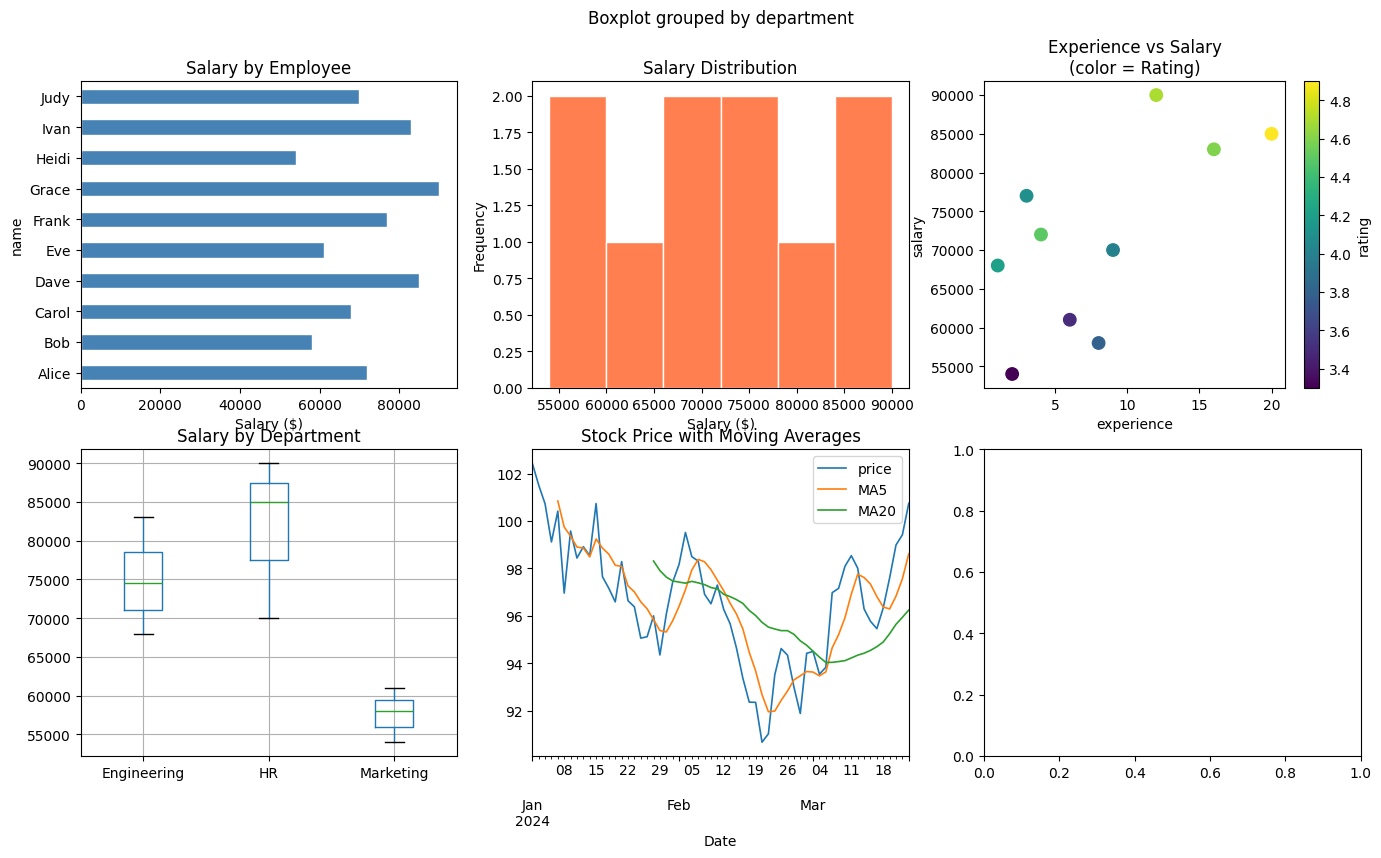

In [111]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Pandas Visualization Gallery', fontsize=16, fontweight='bold', y=1.02)

# --- 1. Bar chart — salary by name ---
df.set_index('name')['salary'].plot(
    kind='barh', ax=axes[0, 0], color='steelblue', edgecolor='white'
)
axes[0, 0].set_title('Salary by Employee')
axes[0, 0].set_xlabel('Salary ($)')

# --- 2. Histogram — salary distribution ---
df['salary'].plot(
    kind='hist', ax=axes[0, 1], bins=6, color='coral', edgecolor='white'
)
axes[0, 1].set_title('Salary Distribution')
axes[0, 1].set_xlabel('Salary ($)')

# --- 3. Scatter — experience vs salary ---
df.plot(
    kind='scatter', x='experience', y='salary', ax=axes[0, 2],
    c='rating', colormap='viridis', s=80
)
axes[0, 2].set_title('Experience vs Salary\n(color = Rating)')

# --- 4. Box plot — salary by department ---
df.boxplot(column='salary', by='department', ax=axes[1, 0])
axes[1, 0].set_title('Salary by Department')
axes[1, 0].set_xlabel('')

# --- 5. Line chart — rolling stock price ---
roll[['price', 'MA5', 'MA20']].plot(ax=axes[1, 1], linewidth=1.2)
axes[1, 1].set_title('Stock Price with Moving Averages')
axes[1, 1].set_xlabel('Date')

# --- 6. KDE — rating distribution ---
df['rating'].plot(kind='kde', ax=axes[1, 2], color='green', linewidth=2)
axes[1, 2].set_title('Rating Distribution (KDE)')
axes[1, 2].set_xlabel('Rating')

plt.tight_layout()
plt.savefig('pandas_plots.png', dpi=100, bbox_inches='tight')
plt.show()
print('Plot saved as pandas_plots.png')

In [ ]:
# === Correlation heatmap using pandas + matplotlib ===
corr = df[['age', 'salary', 'experience', 'rating']].corr()

fig, ax = plt.subplots(figsize=(6, 5))
cax = ax.matshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(cax)

labels = ['Age', 'Salary', 'Experience', 'Rating']
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45)
ax.set_yticklabels(labels)

for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=12)

ax.set_title('Correlation Matrix', pad=20, fontweight='bold')
plt.tight_layout()
plt.show()

---
##  Quick Reference Cheatsheet

### Creation
```python
pd.Series([1, 2, 3])                    # Series from list
pd.DataFrame({'a': [1,2], 'b': [3,4]}) # DataFrame from dict
pd.read_csv('file.csv')                 # from CSV
```

### Inspection
```python
df.head() / df.tail()     # First/last N rows
df.info()                 # Dtypes and non-null counts
df.describe()             # Stats summary
df.shape / df.dtypes      # Shape and types
```

### Selection
```python
df['col']                 # Series
df[['a','b']]             # DataFrame
df.loc[row, col]          # By label
df.iloc[r, c]             # By integer position
df.query('col > 5')       # SQL-style filter
```

### Transformation
```python
df.assign(new=lambda d: ...)     # Add column in chain
df.rename(columns={'old':'new'}) # Rename
df.drop(columns=['a'])           # Drop column
df.drop_duplicates()             # Remove duplicates
df.fillna(0) / df.dropna()      # Handle NaN
```

### GroupBy
```python
df.groupby('dept')['sal'].mean()          # Simple agg
df.groupby('dept').agg(avg=('sal','mean'))# Named agg
df.groupby('dept')['sal'].transform('mean')# Keep shape
```

### Merging
```python
pd.merge(df1, df2, on='key', how='left')  # SQL join
pd.concat([df1, df2], ignore_index=True)  # Stack rows
```

### String & DateTime
```python
s.str.lower() / .str.contains('x')       # String ops
s.dt.year / .dt.month / .dt.day_name()   # Datetime components
s.resample('ME').sum()                    # Downsample
```

### Performance
```python
df['col'].astype('category')              # Lower memory
pd.to_numeric(s, downcast='integer')      # Downcast
pd.read_csv('f.csv', usecols=['a','b'])   # Read less
pd.read_parquet('f.parquet')              # Fast format
```

---
